In [1]:
import pandas as pd
import matplotlib.pyplot as plt


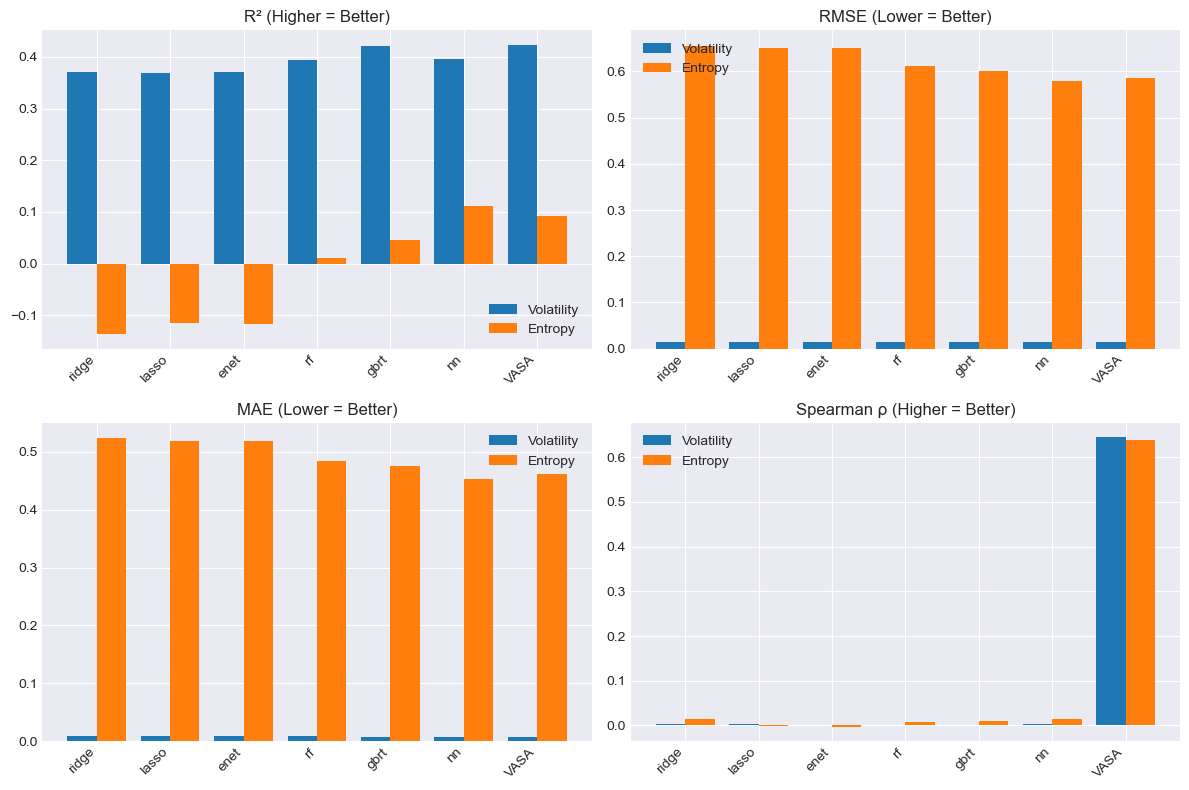

✅ Saved plot to ../data/compare_vasa_vol_entropy.png


In [2]:

# === Load metrics ===
vol_ml = pd.read_csv('../data/vol-output/ml_model_metrics_v.csv', index_col=0)
ent_ml = pd.read_csv('../data/entropy-output/ml_model_metrics_e.csv', index_col=0)
vol_vasa = pd.read_csv('../data/vol-output/vasa_metrics_v.csv', index_col=0)
ent_vasa = pd.read_csv('../data/entropy-output/vasa_metrics_e.csv', index_col=0)

# === Extract test results (VASA Test row only) ===
vol_vasa_test = vol_vasa.loc['Test']
ent_vasa_test = ent_vasa.loc['Test']

# === Combine all models + VASA into one table for comparison ===
vol_all = vol_ml.copy()
vol_all.loc['VASA'] = vol_vasa_test

ent_all = ent_ml.copy()
ent_all.loc['VASA'] = ent_vasa_test

# --- Plot settings ---
plt.style.use('seaborn-v0_8-darkgrid')
metrics = ['R2', 'RMSE', 'MAE', 'Spearman']
titles = ['R² (Higher = Better)', 'RMSE (Lower = Better)', 'MAE (Lower = Better)', 'Spearman ρ (Higher = Better)']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    x = range(len(vol_all))
    
    ax.bar(x, vol_all[metric], width=0.4, label='Volatility', align='center')
    ax.bar([j + 0.4 for j in x], ent_all[metric], width=0.4, label='Entropy', align='center')
    
    ax.set_xticks([j + 0.2 for j in x])
    ax.set_xticklabels(vol_all.index, rotation=45, ha='right')
    ax.set_title(title, fontsize=12)
    ax.legend()

plt.tight_layout()
plt.savefig('../data/compare_vasa_vol_entropy.png', dpi=300)
plt.show()

print("✅ Saved plot to ../data/compare_vasa_vol_entropy.png")


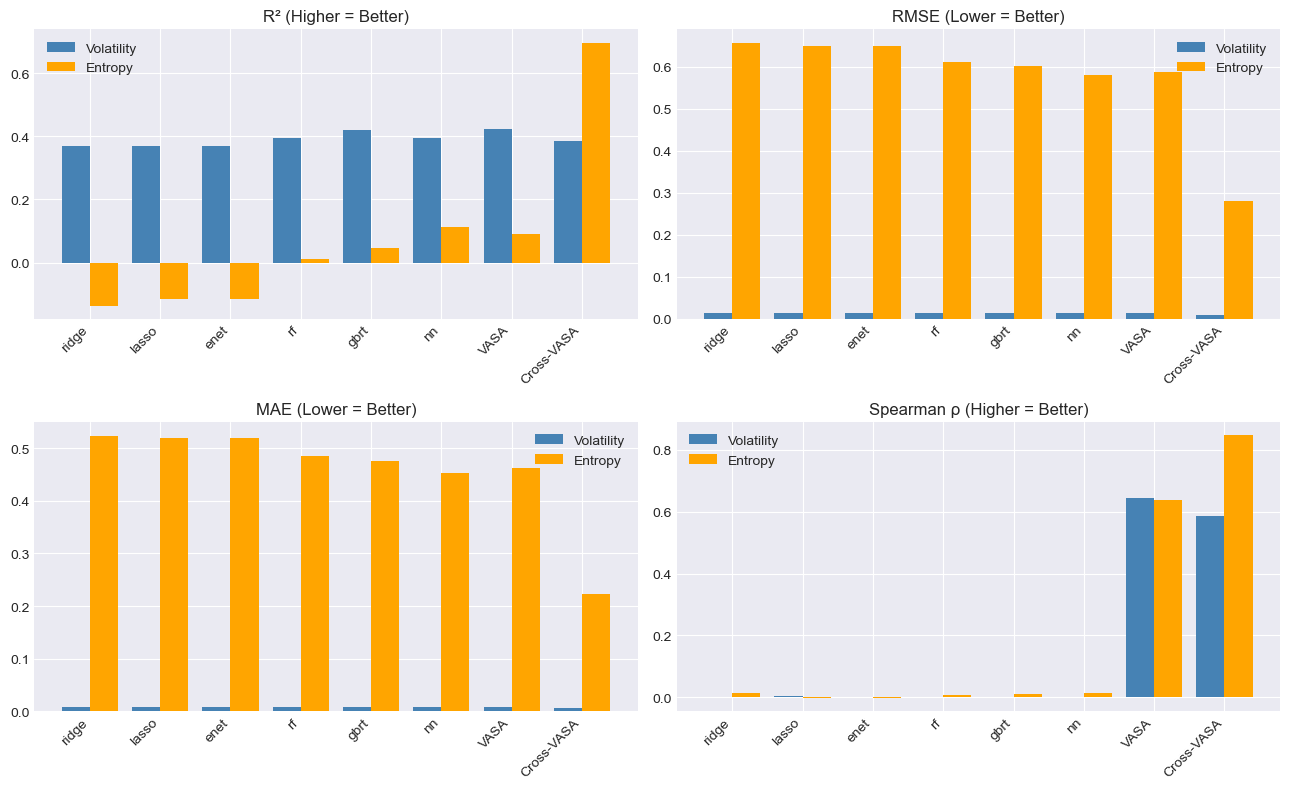

✅ Saved combined plot with VASA and Cross-VASA to ../data/compare_vasa_vol_entropy_full.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load metrics ===
vol_ml = pd.read_csv('../data/vol-output/ml_model_metrics_v.csv', index_col=0)
ent_ml = pd.read_csv('../data/entropy-output/ml_model_metrics_e.csv', index_col=0)

vol_vasa = pd.read_csv('../data/vol-output/vasa_metrics_v.csv', index_col=0)
ent_vasa = pd.read_csv('../data/entropy-output/vasa_metrics_e.csv', index_col=0)

vol_cross = pd.read_csv('../data/vol-output/vasa_cross_metrics_v.csv')
ent_cross = pd.read_csv('../data/entropy-output/vasa_cross_metrics_e.csv')

# === Extract relevant rows ===
vol_vasa_test = vol_vasa.loc['Test']
ent_vasa_test = ent_vasa.loc['Test']

# === Combine all models ===
vol_all = vol_ml.copy()
vol_all.loc['VASA'] = vol_vasa_test
vol_all.loc['Cross-VASA'] = vol_cross.iloc[0]  # single-row file

ent_all = ent_ml.copy()
ent_all.loc['VASA'] = ent_vasa_test
ent_all.loc['Cross-VASA'] = ent_cross.iloc[0]

# === Plot configuration ===
plt.style.use('seaborn-v0_8-darkgrid')
metrics = ['R2', 'RMSE', 'MAE', 'Spearman']
titles = [
    'R² (Higher = Better)',
    'RMSE (Lower = Better)',
    'MAE (Lower = Better)',
    'Spearman ρ (Higher = Better)'
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.ravel()

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i]
    x = range(len(vol_all))
    ax.bar(x, vol_all[metric], width=0.4, label='Volatility', align='center', color='steelblue')
    ax.bar([j + 0.4 for j in x], ent_all[metric], width=0.4, label='Entropy', align='center', color='orange')

    ax.set_xticks([j + 0.2 for j in x])
    ax.set_xticklabels(vol_all.index, rotation=45, ha='right')
    ax.set_title(title, fontsize=12)
    ax.legend()

plt.tight_layout()
plt.savefig('../data/compare_vasa_vol_entropy_full.png', dpi=300)
plt.show()

print("✅ Saved combined plot with VASA and Cross-VASA to ../data/compare_vasa_vol_entropy_full.png")
